Loading cached raw data from /home/solidburak/Documents/Codes/Python/Thesis/data/raw/master_raw_data.parquet...
Engineering stationary features...
Stationary transformation complete. Raw columns purged.
Generating ML-safe expanding GARCH features (This may take a minute)...
Masking the first 252 days of GARCH outputs for stability...
Generating rolling regimes and smoothed targets...
Target generation complete.
Generating lag features for: [1, 2, 3, 5, 10] days...
Preparing data. Target variable: Target_Smooth_10d
Training Samples: 4772 | Testing Samples: 1194
Training XGBoost Classifier...



Model Evaluation on Unseen Test Data (Chronological)
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.95      0.87      0.91      1060
Class 1 (Elevated)       0.09      0.12      0.10        40
   Class 2 (Shock)       0.42      0.71      0.53        94

          accuracy                           0.84      1194
         macro avg       0.48      0.57      0.51      1194
      weighted avg       0.88      0.84      0.85      1194



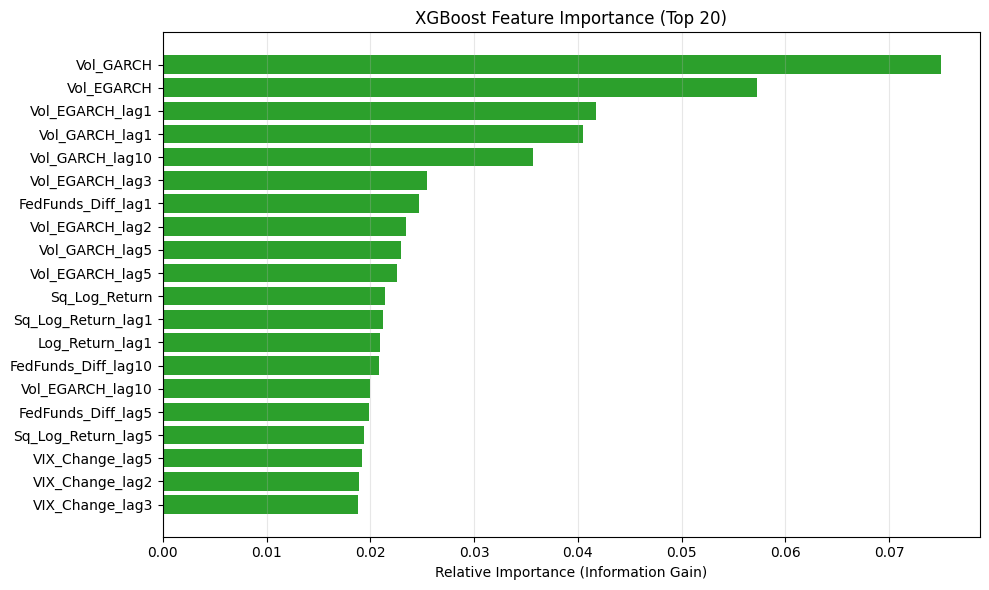

In [2]:
# In your Jupyter Notebook
from src import data_loader, features, volatility, regimes, models_xgb as models

# 1. Ingest
raw_df = data_loader.fetch_raw_data(force_refresh=False)

# 2. Math & Stationarity
stat_df = features.engineer_stationary_features(raw_df)

# 3. GARCH Features
garch_df = volatility.generate_expanding_garch(stat_df, min_obs=252)

# 4. Target Generation (Rolling Regimes & 10d Smooth)
regime_df = regimes.generate_smoothed_targets(
    garch_df, lower_quant=0.83, upper_quant=0.95, floor=0.0
)

# 5. Lags for XGBoost
cols_to_lag = ['Log_Return', 'Sq_Log_Return', 'Vol_GARCH', 'Vol_EGARCH', 
               'VIX_Change', 'Oil_Change', 'CPI_MoM', 'FedFunds_Diff', 'Term_Spread_Diff']
final_df = features.create_lags(regime_df, feature_cols=cols_to_lag)

# 6. Train & Evaluate
model, feature_names, X_test, y_test = models.train_xgboost_baseline(final_df)
models.plot_feature_importance(model, feature_names)

==================================================
Model Evaluation on Unseen Test Data (Chronological)
==================================================
                    precision    recall  f1-score   support

    Class 0 (Calm)       0.97      0.90      0.93      1088
Class 1 (Elevated)       0.00      0.00      0.00        12
   Class 2 (Shock)       0.42      0.72      0.53        94

          accuracy                           0.88      1194
         macro avg       0.46      0.54      0.49      1194
      weighted avg       0.91      0.88      0.89      1194

